===== IQR 방법 =====
중앙값: 70.0
Q1: 66.0
Q3: 76.5
IQR: 10.5
하한: 50.25
상한: 92.25
최소값: 60
최대값: 200
IQR 이상치:
9      95
10    200
dtype: int64


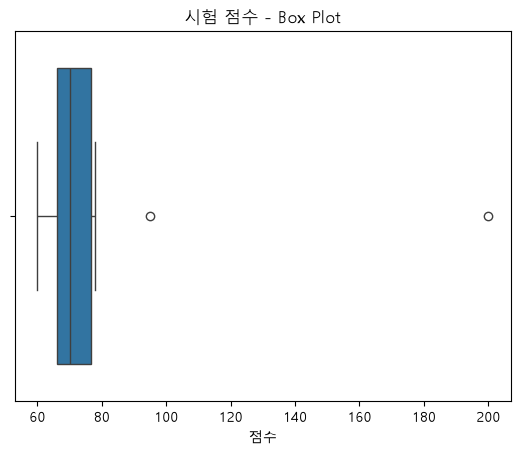


===== Z-score 방법 =====
평균: 82.91
분산: 1453.36
표준편차: 38.12
Z-score:
[-0.6  -0.55 -0.47 -0.42 -0.39 -0.34 -0.29 -0.21 -0.13  0.32  3.07]
Z-score 이상치:
[200]


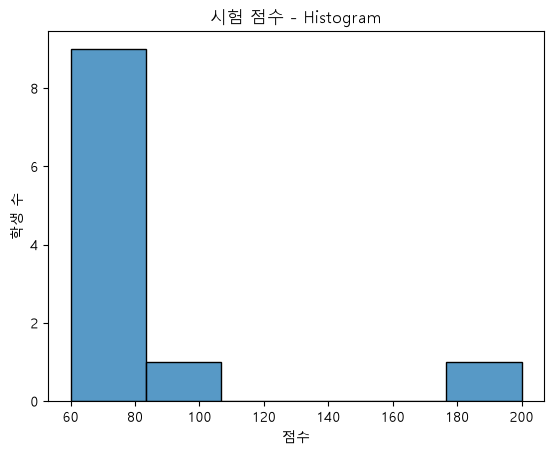

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 1. 데이터 준비
# ============================================================

scores = [60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200]

scores_np = np.array(scores)
scores_series = pd.Series(scores)


# ============================================================
# 2. IQR 방법
# ============================================================

print("===== IQR 방법 =====")

# 중앙값
median = scores_series.median()

# Q1, Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 기준
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 최소값, 최대값
minimum = scores_series.min()
maximum = scores_series.max()

print("중앙값:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower)
print("상한:", upper)
print("최소값:", minimum)
print("최대값:", maximum)

# 이상치
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQR 이상치:")
print(outliers_iqr)


# ============================================================
# 3. 박스플롯
# ============================================================

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()


# ============================================================
# 4. Z-score 방법
# ============================================================

print()
print("===== Z-score 방법 =====")


# 기술 통계량은 같은 데이터를 사용해도 NumPy 배열과 Pandas Series는 제공하는 기능과 기본값에 차이가 있다.
# NumPy는 주로 모집단을 기준으로 하고, Pandas는 표본을 기준으로 한다.

# 평균
mean = scores_np.mean()

# 분산
variance = scores_np.var()

# 표준편차
std = scores_np.std()

print("평균:", round(mean, 2))
print("분산:", round(variance, 2))
print("표준편차:", round(std, 2))


# Z-score 계산
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))


# ============================================================
# 5. Z-score 이상치 판단
# ============================================================

outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-score 이상치:")
print(outliers_z)


# ============================================================
# 6. 히스토그램
# ============================================================

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()



과제 1 : 200 제거 후 이상치 판별

===== 과제 1 - IQR 방법 =====
중앙값: 69.0
Q1: 65.5
Q3: 74.25
IQR: 8.75
하한: 52.375
상한: 87.375
최소값: 60
최대값: 95
IQR 이상치:
9    95
dtype: int64

===== 과제 1 - Z-score 방법 =====
평균: 71.2
분산: 90.56
표준편차: 9.52
Z-score:
[-1.18 -0.97 -0.65 -0.44 -0.34 -0.13  0.08  0.4   0.71  2.5 ]
Z-score 이상치:
[]


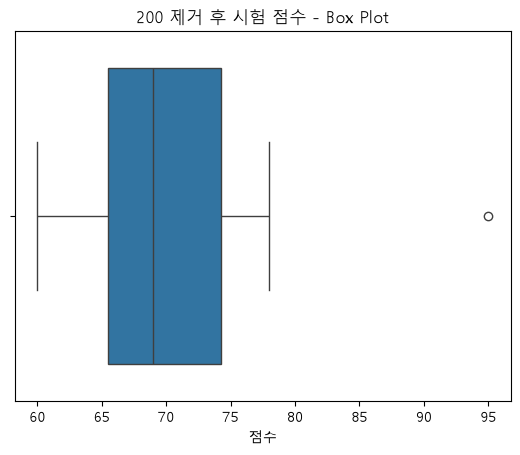

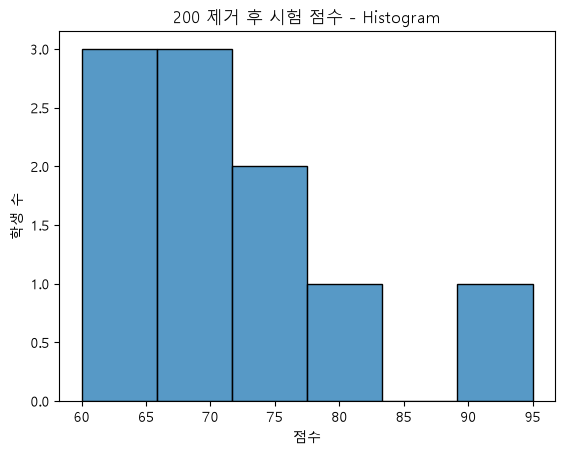

In [2]:
# ============================================================
# 과제 1
# 200이라는 이상치 값을 제거 후 다시 2가지 방법으로 이상치 판별
# ============================================================

print()
print()
print("============================================================")
print("과제 1 : 200 제거 후 이상치 판별")
print("============================================================")

# 200 제거
scores_clean = scores_series[scores_series != 200]

scores_clean_np = scores_clean.to_numpy()


# ------------------------------------------------------------
# 과제 1 - IQR 방법
# ------------------------------------------------------------

print()
print("===== 과제 1 - IQR 방법 =====")

median_clean = scores_clean.median()

Q1_clean = scores_clean.quantile(0.25)
Q3_clean = scores_clean.quantile(0.75)

IQR_clean = Q3_clean - Q1_clean

lower_clean = Q1_clean - 1.5 * IQR_clean
upper_clean = Q3_clean + 1.5 * IQR_clean

minimum_clean = scores_clean.min()
maximum_clean = scores_clean.max()

print("중앙값:", median_clean)
print("Q1:", Q1_clean)
print("Q3:", Q3_clean)
print("IQR:", IQR_clean)
print("하한:", lower_clean)
print("상한:", upper_clean)
print("최소값:", minimum_clean)
print("최대값:", maximum_clean)

outliers_iqr_clean = scores_clean[
    (scores_clean < lower_clean) | (scores_clean > upper_clean)
]

print("IQR 이상치:")
print(outliers_iqr_clean)


# ------------------------------------------------------------
# 과제 1 - Z-score 방법
# ------------------------------------------------------------

print()
print("===== 과제 1 - Z-score 방법 =====")

mean_clean = scores_clean_np.mean()

variance_clean = scores_clean_np.var()

std_clean = scores_clean_np.std()

print("평균:", round(mean_clean, 2))
print("분산:", round(variance_clean, 2))
print("표준편차:", round(std_clean, 2))


z_scores_clean = (scores_clean_np - mean_clean) / std_clean

print("Z-score:")
print(np.round(z_scores_clean, 2))


outliers_z_clean = scores_clean_np[
    np.abs(z_scores_clean) > 3
]

print("Z-score 이상치:")
print(outliers_z_clean)


# ------------------------------------------------------------
# 과제 1 - 박스플롯
# ------------------------------------------------------------

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_clean, ax=axes1)

axes1.set_title("200 제거 후 시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()


# ------------------------------------------------------------
# 과제 1 - 히스토그램
# ------------------------------------------------------------

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_clean, bins=6, ax=axes1)

axes1.set_title("200 제거 후 시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()



과제 2 : 새로운 데이터 이상치 판별

===== 과제 2 - IQR 방법 =====
중앙값: 75.0
Q1: 71.0
Q3: 79.0
IQR: 8.0
하한: 59.0
상한: 91.0
최소값: 30
최대값: 125
IQR 이상치:
0      30
1      35
97    115
98    120
99    125
dtype: int64

===== 과제 2 - Z-score 방법 =====
평균: 75.46
분산: 121.27
표준편차: 11.01
Z-score:
[-4.13 -3.67 -0.68 -0.31 -0.04 -0.5  -0.95  0.23  0.59 -0.13 -0.59 -0.41
  0.05  0.41 -0.22 -0.77  0.14  0.78  0.32 -0.31 -0.86  0.5  -0.5  -0.04
  0.68 -0.68 -0.13  0.23 -0.41  0.87  0.05 -0.59 -0.22  0.41  0.14 -0.31
 -0.68  0.59 -0.04 -0.5   0.32 -0.13 -0.77  0.5   0.05 -0.22  0.23 -0.59
  0.78 -0.41 -0.04  0.41 -0.31  0.14 -0.68 -0.13  0.59  0.32 -0.5   0.05
  0.87 -0.22 -0.59  0.5  -0.04  0.23 -0.31 -0.77  0.41 -0.13  0.14 -0.41
  0.68  0.05 -0.5   0.32 -0.22 -0.68  0.59 -0.04 -0.41  0.23 -0.13  0.41
 -0.59  0.14 -0.31  0.5   0.05 -0.5   0.78 -0.22 -0.04  0.32 -0.68  0.59
 -0.13  3.59  4.04  4.5 ]
Z-score 이상치:
[ 30  35 115 120 125]


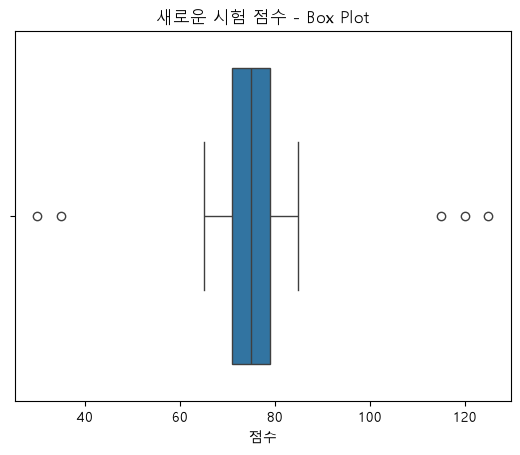

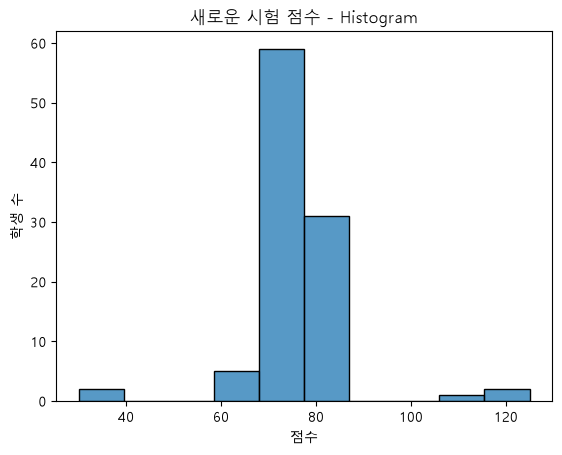

In [3]:
# ============================================================
# 과제 2
# 주어진 데이터를 활용하여 이상치 판별
# ============================================================

print()
print()
print("============================================================")
print("과제 2 : 새로운 데이터 이상치 판별")
print("============================================================")


# 데이터 준비
scores2 = [
    30, 35, 68, 72, 75, 70, 65, 78, 82, 74,
    69, 71, 76, 80, 73, 67, 77, 84, 79, 72,
    66, 81, 70, 75, 83, 68, 74, 78, 71, 85,
    76, 69, 73, 80, 77, 72, 68, 82, 75, 70,
    79, 74, 67, 81, 76, 73, 78, 69, 84, 71,
    75, 80, 72, 77, 68, 74, 82, 79, 70, 76,
    85, 73, 69, 81, 75, 78, 72, 67, 80, 74,
    77, 71, 83, 76, 70, 79, 73, 68, 82, 75,
    71, 78, 74, 80, 69, 77, 72, 81, 76, 70,
    84, 73, 75, 79, 68, 82, 74, 115, 120, 125
]

scores2_np = np.array(scores2)
scores2_series = pd.Series(scores2)


# ------------------------------------------------------------
# 과제 2 - IQR 방법
# ------------------------------------------------------------

print()
print("===== 과제 2 - IQR 방법 =====")

median2 = scores2_series.median()

Q1_2 = scores2_series.quantile(0.25)
Q3_2 = scores2_series.quantile(0.75)

IQR_2 = Q3_2 - Q1_2

lower2 = Q1_2 - 1.5 * IQR_2
upper2 = Q3_2 + 1.5 * IQR_2

minimum2 = scores2_series.min()
maximum2 = scores2_series.max()

print("중앙값:", median2)
print("Q1:", Q1_2)
print("Q3:", Q3_2)
print("IQR:", IQR_2)
print("하한:", lower2)
print("상한:", upper2)
print("최소값:", minimum2)
print("최대값:", maximum2)


outliers_iqr2 = scores2_series[
    (scores2_series < lower2) | (scores2_series > upper2)
]

print("IQR 이상치:")
print(outliers_iqr2)


# ------------------------------------------------------------
# 과제 2 - Z-score 방법
# ------------------------------------------------------------

print()
print("===== 과제 2 - Z-score 방법 =====")

mean2 = scores2_np.mean()

variance2 = scores2_np.var()

std2 = scores2_np.std()

print("평균:", round(mean2, 2))
print("분산:", round(variance2, 2))
print("표준편차:", round(std2, 2))


z_scores2 = (scores2_np - mean2) / std2

print("Z-score:")
print(np.round(z_scores2, 2))


outliers_z2 = scores2_np[
    np.abs(z_scores2) > 3
]

print("Z-score 이상치:")
print(outliers_z2)


# ------------------------------------------------------------
# 과제 2 - 박스플롯
# ------------------------------------------------------------

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores2_series, ax=axes1)

axes1.set_title("새로운 시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()


# ------------------------------------------------------------
# 과제 2 - 히스토그램
# ------------------------------------------------------------

fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores2_series, bins=10, ax=axes1)

axes1.set_title("새로운 시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()